In [3]:
import numpy as np
import joblib
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score


# File paths
SAVE_PATH = "../../processed_data/SDHAR/"
TREE_DATA_FILE = os.path.join(SAVE_PATH, "tree_small_window_smote_band_data.npz")

# Save paths
MODEL_SAVE_PATH = "../../models/SDHAR/"
if not os.path.exists(MODEL_SAVE_PATH):
    os.makedirs(MODEL_SAVE_PATH)

activity_names = ["BATHROOM ACTIVITY", "CHORES", "COOK", "DISHWASHING", "DRESS", "EAT", "LAUNDRY",
                  "MAKE SIMPLE FOOD", "OUT HOME", "PET", "READ", "RELAX", "SHOWER", "SLEEP",
                  "TAKE MEDS", "WATCH TV", "WORK", "OTHER"]

In [4]:
from sklearn.ensemble import RandomForestClassifier


def train_and_save_rf_numpy_heatmap(save_path, data_file, output_name):
    activity_names = ["BATHROOM ACTIVITY", "CHORES", "COOK", "DISHWASHING", "DRESS", "EAT", "LAUNDRY",
                      "MAKE SIMPLE FOOD", "OUT HOME", "PET", "READ", "RELAX", "SHOWER", "SLEEP",
                      "TAKE MEDS", "WATCH TV", "WORK", "OTHER"]

    print(f"Loading data from {data_file}...")
    data = np.load(data_file)
    X_train = data['X_train']
    y_train = data['y_train']
    X_test = data['X_test']
    y_test = data['y_test']

    print("\nBuilding and training the Random Forest model on SMOTE data...")
    model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model_rf.fit(X_train, y_train)
    print("  - Model training complete!")

    print("\nEvaluating the RF model on the *original* (unbalanced) test set...")
    y_pred = model_rf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

    print("\nGenerating Classification Report Heatmap...")

    report_dict = classification_report(y_test, y_pred, target_names=activity_names, output_dict=True)

    df_report = pd.DataFrame(report_dict).transpose()

    df_metrics = df_report.drop(columns=['support'])
    plt.figure(figsize=(12, 10)) # Adjust size for your number of classes

    sns.heatmap(
        df_metrics,
        annot=True,         # Show the numbers in the boxes
        cmap='Blues',       # Color scheme (Blues, YlGnBu, etc.)
        fmt='.2f',          # Format numbers to 2 decimal places
        vmin=0.0, vmax=1.0  # Force scale between 0 and 1
    )

    plt.title("Classification Report Heatmap")
    plt.yticks(rotation=0)  # Keep y-axis labels horizontal
    plot_path = os.path.join(save_path, "classification_report_heatmap.png")
    plt.savefig(plot_path, bbox_inches='tight')
    print(f"  - Heatmap saved to {plot_path}")

    plt.show()

    print("Saving the RF model...")
    joblib.dump(model_rf, os.path.join(save_path, output_name))
    print("  - Model saved successfully!")

Loading data from ../../processed_data/SDHAR/tree_small_window_smote_band_data.npz...

Building and training the Random Forest model on SMOTE data...
  - Model training complete!

Evaluating the RF model on the *original* (unbalanced) test set...

Test Accuracy: 98.33%

Generating Classification Report Heatmap...
  - Heatmap saved to ../../models/SDHAR/classification_report_heatmap.png


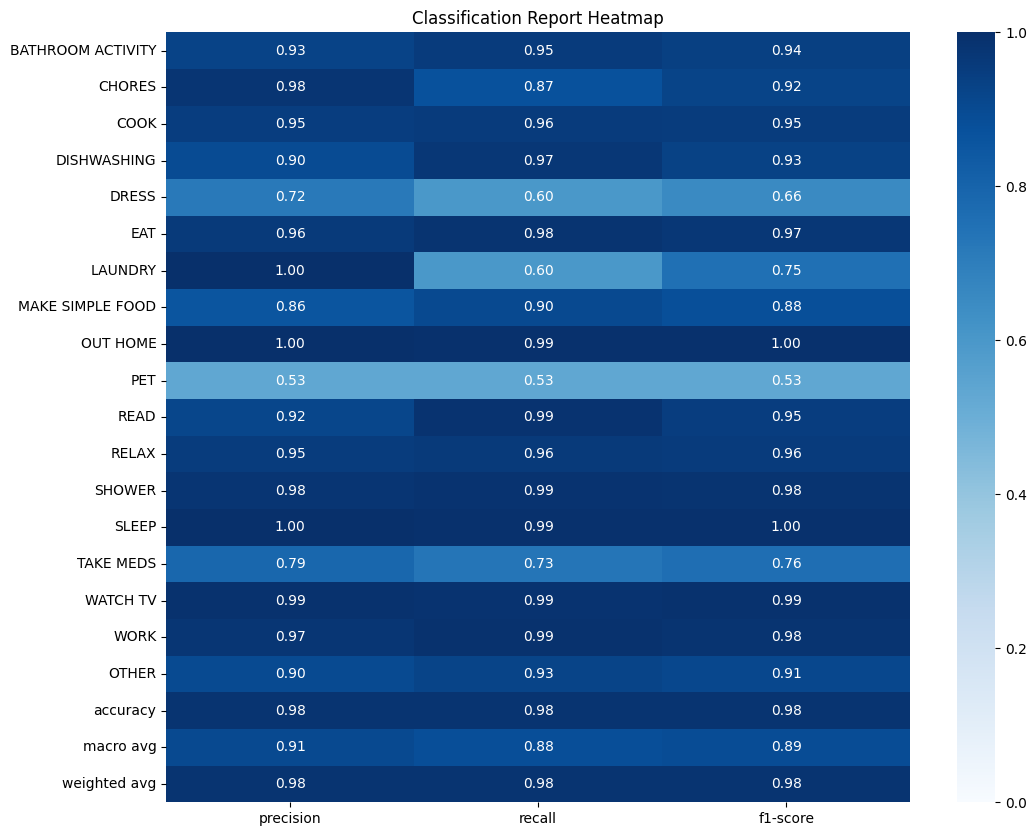

Saving the RF model...
  - Model saved successfully!


In [5]:
output_name = "RandomForest_small_window_smote_band_final.joblib"
train_and_save_rf_numpy_heatmap(MODEL_SAVE_PATH, TREE_DATA_FILE, output_name)